In [2]:
'''
    Vertical Profile Plots from CAM simulations
'''

'\n    Vertical Profile Plots from \n'

In [3]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as mp

In [4]:
'''
    Set Parameters
'''

season = 'DJF'
var_plot = 'ZMDT'

cam_runs = ['f.cam6_3_161.FLTHIST_ne30.ke.000b','f.cam6_3_161.FLTHIST_ne30.ke.001']
cam_names = ['1deg CAM7','+ZM-KE']


dir_climo = '/glade/derecho/scratch/rneale/archive/'


0  -  1deg CAM7  - f.cam6_3_161.FLTHIST_ne30.ke.000b
Coordinates:
  * lev      (lev) float64 464B 3.018 5.445 9.087 14.25 ... 983.2 991.2 997.5


TypeError: unhashable type: 'DataArray'

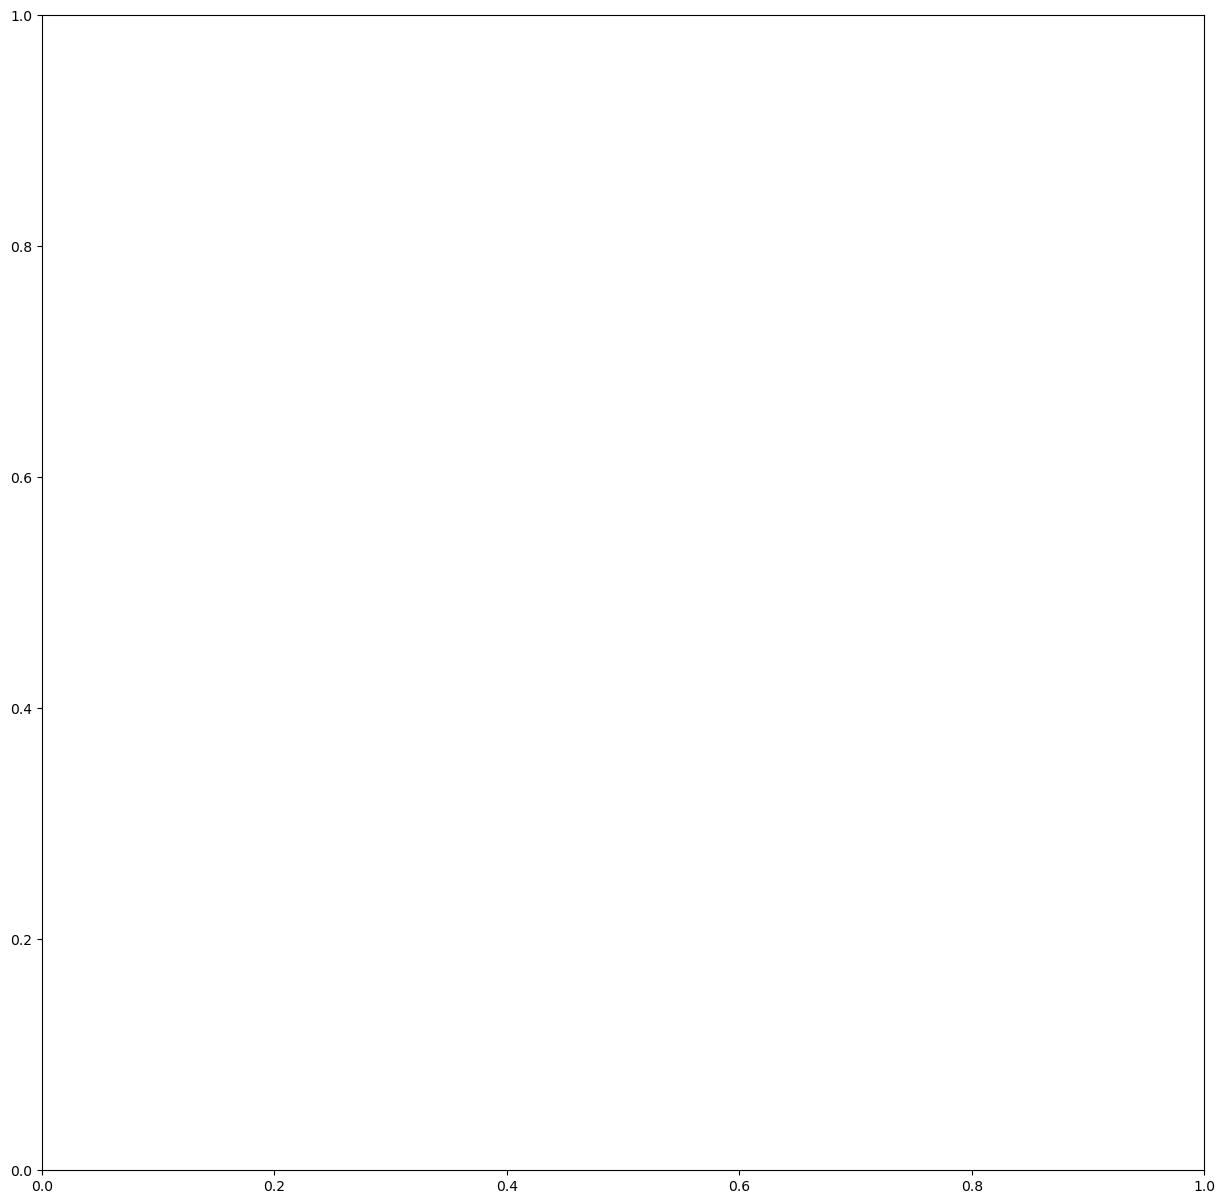

In [6]:
'''
    Loop Cases
'''


fig, ax = mp.subplots(nrows=1,ncols=1,
                        figsize=(15,15))

lats = -10.  ; latn = 5.
lonw = 140. ; lone = 160.


lat_bounds = slice(lats, latn)  # Latitude bounds
lon_bounds = slice(lonw, lone)  # Longitude bounds

for icase,case in enumerate(cam_runs):

    print()
    print(icase,' - ',cam_names[icase],' - '+case)
    
    file_in = dir_climo+cam_runs[icase]+'/climo/'+cam_runs[icase]+'_'+season+'_climo.nc'  
    
    
    ds_ic = xr.open_dataset(file_in)

    da_ic = ds_ic[var_plot]
    da_ic = da_ic.sel(lat=lat_bounds, lon=lon_bounds).mean(dim=["lat", "lon"])
    print(da_ic.coords)
    da_ic.plot(ax=ax,y=da_ic['lev'])
    
    